# Part 1 - How good is the v0 model?

A while back I set out to rebuild xwOBA from scratch as a Bayesian model. What came out is what I'm calling **v0**: a BART (Bayesian Additive Regression Trees) categorical model that predicts a batted ball's outcome from just three contact measurements — launch speed, launch angle, and sprint speed — and rolls those probabilities up into an expected-wOBA number for each hitter. That's the same information set public Baseball Savant xwOBA is built on, so the very first thing I want to know is: did I actually reproduce it?

Before doing anything clever with the model, let me check how faithful it is. I'll load the run artifacts from `results/stage_{A,B,C}/` and take a look.

The short version: player-season correlation with Savant lands around **0.96** (for hitters with 100+ PA), calibration error is about **0.04**, and — this surprised me — the quality saturates early, by roughly 50k training rows (Stage B). Stage C, on 100k rows, matches it within noise.

In [1]:
# --- setup: find repo root, load helpers (run this first) ---
import sys, json
from pathlib import Path
import polars as pl
from IPython.display import Image, Markdown, display

pl.Config.set_tbl_rows(30)
here = Path.cwd()
ROOT = next((p for p in [here, *here.parents] if (p / "config.yaml").exists()), here)
sys.path.insert(0, str(ROOT))
RESULTS = ROOT / "results"

def jload(rel):
    return json.loads((RESULTS / rel).read_text())

def show_fig(rel, width=680):
    p = RESULTS / rel
    return Image(filename=str(p), width=width) if p.exists() else Markdown(f"_missing figure: {rel}_")

print("repo root:", ROOT)
print("results:  ", RESULTS, "(exists)" if RESULTS.exists() else "(MISSING)")

repo root: /Users/jweinga/Documents/python/xwobart
results:   /Users/jweinga/Documents/python/xwobart/results (exists)


## Quality across the three fit stages

I fit the model in three stages. Stage A is a tiny smoke run (5k rows) — just enough to check the wiring, so I expect weak numbers there. The real comparison is B (50k rows) versus C (100k rows). If C looks about the same as B, that tells me the model is already data-saturated by ~50k rows and there's little point paying for more.

One caveat on the table below: ELPD isn't comparable across stages, since each one predicts a different number of held-out events.

In [2]:
rows = []
for stage in ("stage_A", "stage_B", "stage_C"):
    m = jload(f"{stage}/metrics.json")
    rep, elpd = m["replication"], m["elpd"]
    rows.append({
        "stage": stage.replace("stage_", ""),
        "fit_rows": m.get("fit_rows"),
        "player_r_holdout": round(rep["player_r_holdout"], 4),
        "event_r_holdout": round(rep["event_r_holdout"], 4),
        "calib_ece": round(m["calibration"]["per_class"]["out"]["ece"], 4),
        "elpd_lppd": round(elpd["elpd_lppd"], 0),
        "elpd_se": round(elpd["elpd_se"], 0),
    })
pl.DataFrame(rows)

stage,fit_rows,player_r_holdout,event_r_holdout,calib_ece,elpd_lppd,elpd_se
str,i64,f64,f64,f64,f64,f64
"""A""",5000,0.4551,0.8398,0.0896,-14401.0,101.0
"""B""",50000,0.9628,0.9162,0.0381,-80023.0,246.0
"""C""",100000,0.956,0.9105,0.0424,-80107.0,244.0


For Stage C, `elpd_lppd` comes in at **−80107 ± 244** over 122k holdout events — that's the anchor any future model version has to beat. Notice that player r barely climbs from A to C and ELPD hardly moves at all: three features get you most of the way there, and they get you there fast.

## Feature importance

So which of the three features is doing the work? The numbers below are cumulative R² — how much of the model's explanatory power each feature accounts for.

In [3]:
vi = jload("stage_C/metrics.json")["variable_importance"]
pl.DataFrame({"feature": vi["feature_labels"],
              "r2_mean_cumulative": [round(x, 4) for x in vi["raw"]["r2_mean"]]})

feature,r2_mean_cumulative
str,f64
"""launch_speed""",0.8526
"""launch_angle""",0.8609
"""sprint_speed""",0.8621


## The pictures (Stage C)

Numbers are one thing; let me actually look at what the model is doing.

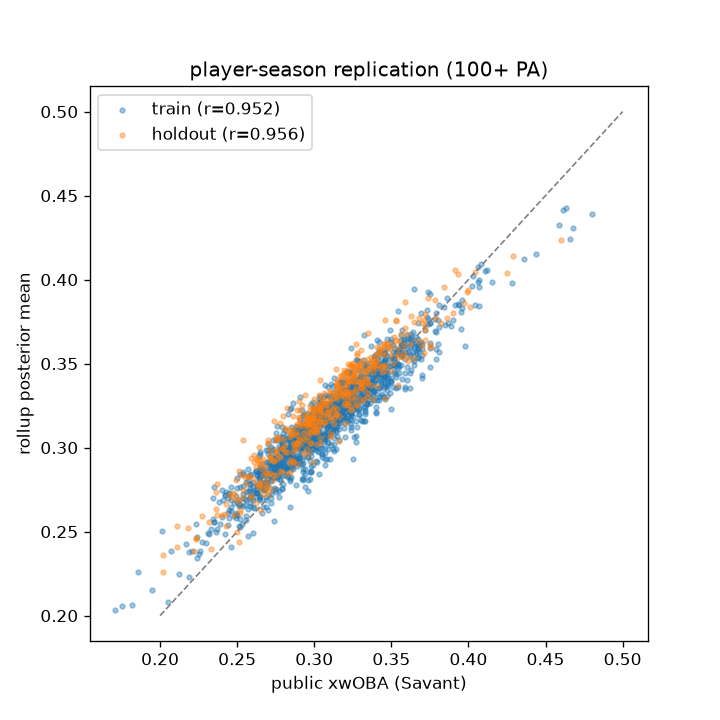

In [4]:
show_fig("stage_C/figures/replication_player.png")

Here's the headline plot: model xwOBA against Savant xwOBA, one point per player-season. That tight diagonal is the 0.96 correlation — the model is faithfully tracking Savant.

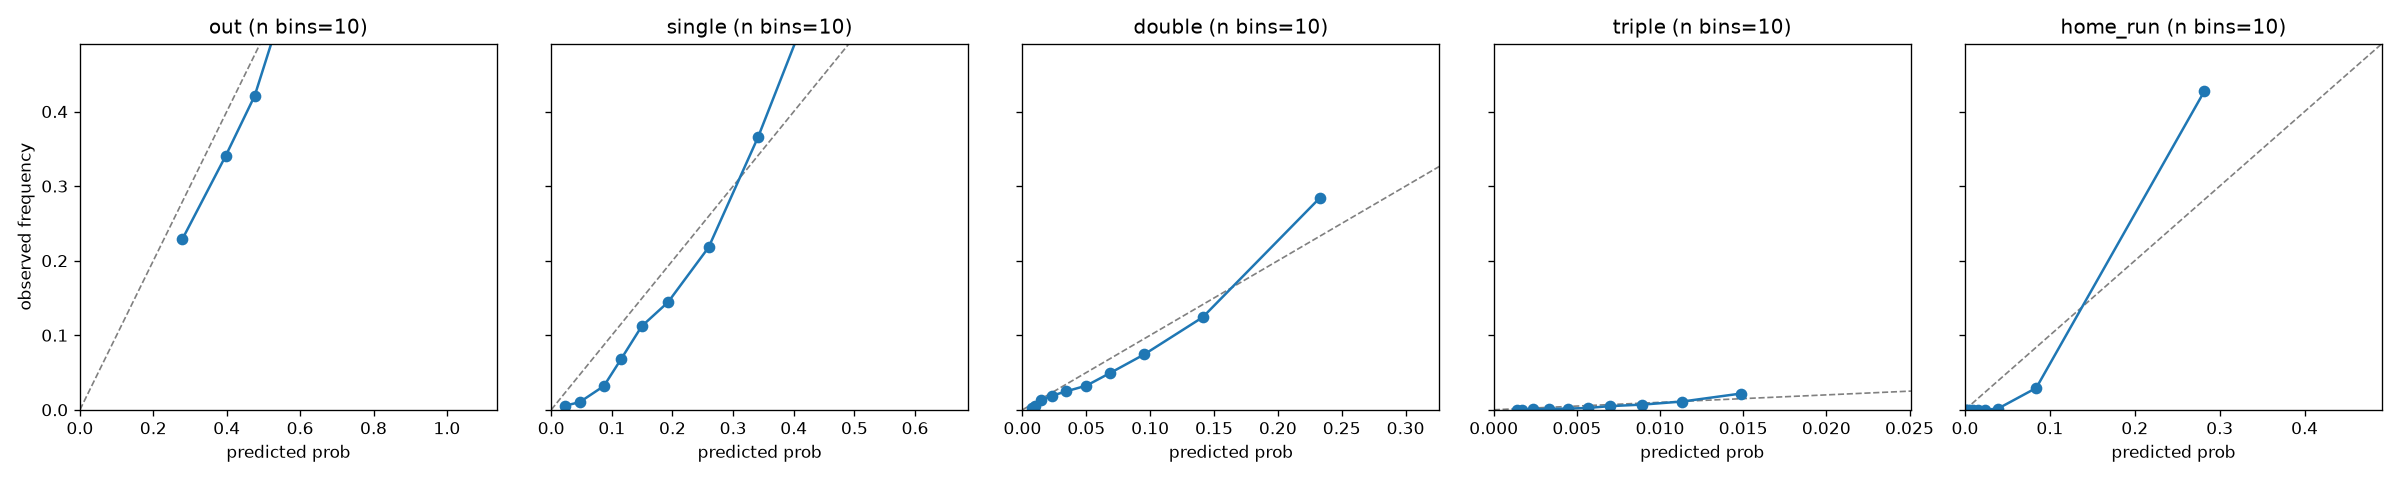

In [5]:
show_fig("stage_C/figures/calibration_reliability.png")

Next, calibration: predicted outcome frequency against what actually happened. Points hugging the diagonal mean the probabilities are honest, not just well-ordered (ECE ≈ 0.04).

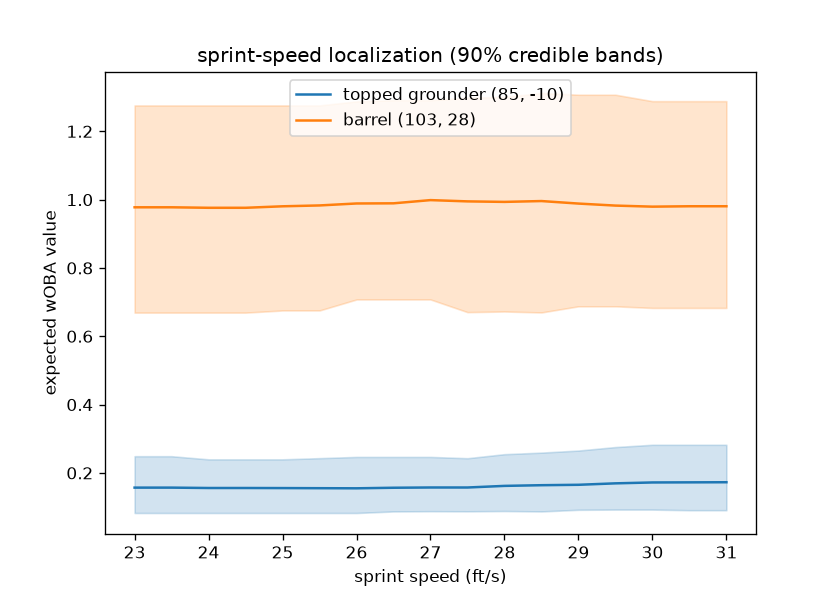

In [6]:
show_fig("stage_C/figures/sprint_localization_curves.png")

And this is the sprint-speed story. Weak, topped contact gains xwOBA as the runner gets faster, while barrels stay flat — which is exactly right when you think about it: a fast runner can beat out a weak grounder, but nobody outruns a ball hit into the seats.

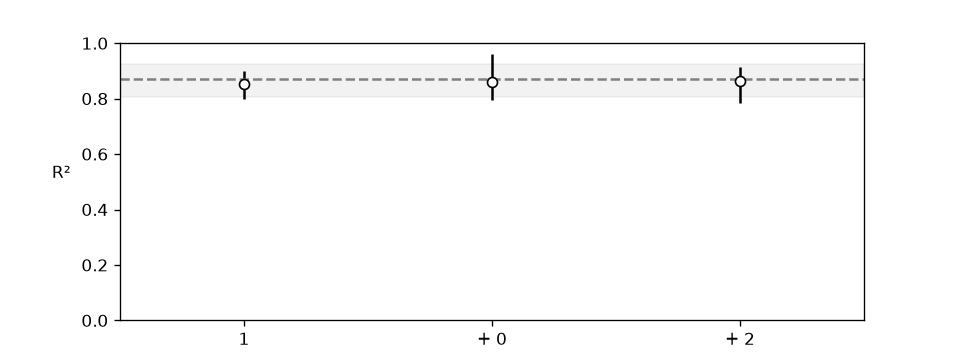

In [7]:
show_fig("stage_C/figures/variable_importance.png")

## Takeaway

So v0 is a faithful, well-calibrated reconstruction of xwOBA from three contact features. That's reassuring — but it raises the obvious next question: is it any *more accurate* than Savant itself, or did I just rebuild the same thing? That's what Part 2 is about.